# Introduction to Machine Learning
Author: Jennifer Danielson  
(https://github.com/jmdanielson82/datafun-07-ml)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Part 1 - Chart a Straight Line
In this section, I refresh linear regression fundamentals by plotting a simple linear relationship (Celsius → Fahrenheit).

In [2]:
celsius = np.arange(0, 101, 10)
fahrenheit = (9/5) * celsius + 32

temps_df = pd.DataFrame({"Celsius": celsius, "Fahrenheit": fahrenheit})
temps_df

,Celsius,Fahrenheit
0,0,32.0
1,10,50.0
2,20,68.0
3,30,86.0
4,40,104.0
5,50,122.0
6,60,140.0
7,70,158.0
8,80,176.0
9,90,194.0


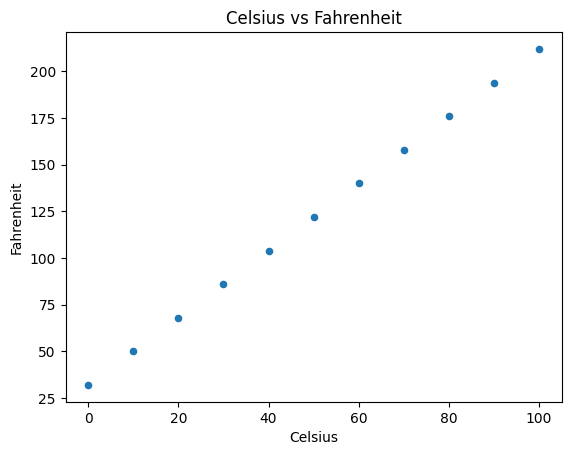

In [3]:
ax = temps_df.plot(x="Celsius", y="Fahrenheit", kind="scatter", title="Celsius vs Fahrenheit")
ax.set_xlabel("Celsius")
ax.set_ylabel("Fahrenheit")
plt.show()

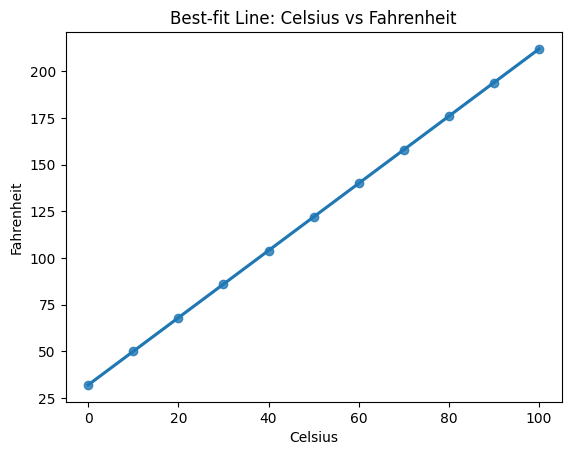

In [4]:
sns.regplot(data=temps_df, x="Celsius", y="Fahrenheit")
plt.title("Best-fit Line: Celsius vs Fahrenheit")
plt.show()

## Part 2 - Prediction Using SciPy Linear Regression

### Section 1 - Data Acquisition

In [5]:
nyc_df = pd.read_csv("../data/raw/ave_hi_nyc_jan_1895-2018.csv")
nyc_df.head()

,Date,Value,Anomaly
0,189501,34.2,-3.2
1,189601,34.7,-2.7
2,189701,35.5,-1.9
3,189801,39.6,2.2
4,189901,36.4,-1.0


### Section 2 - Data Inspection

In [6]:
nyc_df.head()
nyc_df.tail()

,Date,Value,Anomaly
119,201401,35.5,-1.9
120,201501,36.1,-1.3
121,201601,40.8,3.4
122,201701,42.8,5.4
123,201801,38.7,1.3


### Section 3 - Data Cleaning

In [7]:
nyc_df = nyc_df.iloc[:, :2]   # keeps first two columns only
nyc_df.columns = ["Year", "AvgHighTemp"]
nyc_df.head()

,Year,AvgHighTemp
0,189501,34.2
1,189601,34.7
2,189701,35.5
3,189801,39.6
4,189901,36.4


In [8]:
nyc_df["Year"] = nyc_df["Year"].astype(str).str[:4].astype(int)
nyc_df.head()

,Year,AvgHighTemp
0,1895,34.2
1,1896,34.7
2,1897,35.5
3,1898,39.6
4,1899,36.4


### Section 4 - Descriptive Statistics

In this section, I calculate summary statistics for the dataset to better understand the distribution of average January high temperatures in New York City.

Using the `describe()` function, I examine:

- Count (number of years recorded)
- Mean average temperature
- Standard deviation
- Minimum and maximum values
- Quartiles (25%, 50%, 75%)

These statistics provide insight into the overall trend and variability of January temperatures over time before building the regression model.

In [9]:
pd.set_option("display.precision", 2)
nyc_df.describe()

,Year,AvgHighTemp
count,124.00,124.00
mean,1956.50,37.60
std,35.94,4.54
min,1895.00,26.10
25%,1925.75,34.58
50%,1956.50,37.60
75%,1987.25,40.60
max,2018.00,47.60


### Section 5 - Build the Model

To model the relationship between year and average January high temperature, I use SciPy's `linregress()` function. This function calculates the slope and intercept of the best-fit line using simple linear regression.

The resulting equation follows the form:

y = mx + b

Where:
- m is the slope (rate of temperature change per year)
- b is the intercept

In [10]:
slope, intercept, r_value, p_value, std_err = stats.linregress(
    nyc_df["Year"],
    nyc_df["AvgHighTemp"]
)

slope, intercept, r_value

(np.float64(0.014771361132966163),
 np.float64(8.694993233674289),
 np.float64(0.1169376670075292))

### Section 6 - Predict

Using the regression equation (y = mx + b), I predict the average January high temperature for the year 2024.

In [11]:
prediction_2024 = slope * 2024 + intercept
print(f"Predicted NYC avg high temp in Jan 2024: {prediction_2024:.2f}°F")

Predicted NYC avg high temp in Jan 2024: 38.59°F


### Section 7 - Visualizations

To better understand the relationship between year and temperature, I visualize the data using a scatter plot with a best-fit regression line.

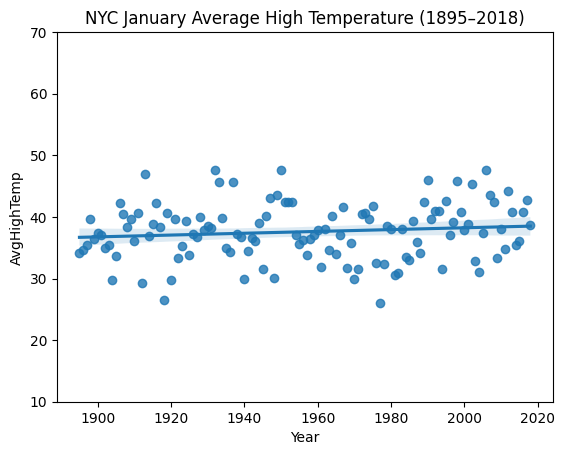

In [12]:
axes = sns.regplot(x="Year", y="AvgHighTemp", data=nyc_df)

axes.set_ylim(10, 70)
plt.title("NYC January Average High Temperature (1895–2018)")
plt.show()

## Part 3 - Prediction Using Scikit-Learn

### Section 1 - Build the Model

In this section, I use Scikit-Learn's LinearRegression estimator. 
The dataset is split into training and testing subsets to simulate 
real-world machine learning workflow.

In [13]:
X = nyc_df[["Year"]]
y = nyc_df["AvgHighTemp"]

X.shape, y.shape

((124, 1), (124,))

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=11
)

X_train.shape, X_test.shape

((93, 1), (31, 1))

In [15]:
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
linear_regression.coef_
linear_regression.intercept_

np.float64(-0.30779820252656975)

In [17]:
print("Slope (coef_):", linear_regression.coef_[0])
print("Intercept:", linear_regression.intercept_)

Slope (coef_): 0.019391673294782773
Intercept: -0.30779820252656975


### Section 2 - Test the Model

I evaluate the trained model by comparing predicted values with actual values from the test dataset.

In [18]:
predicted = linear_regression.predict(X_test)

for p, e in zip(predicted[:5], y_test[:5]):
    print(f"Predicted: {p:.2f}, Expected: {e:.2f}")

Predicted: 37.86, Expected: 31.70
Predicted: 36.48, Expected: 35.50
Predicted: 37.93, Expected: 40.50
Predicted: 36.61, Expected: 29.80
Predicted: 36.75, Expected: 40.70


### Section 3 - Predict

Using the trained Scikit-Learn model, I predict the average January high temperature for 2024.

In [19]:
prediction_2024_sklearn = linear_regression.predict(
    pd.DataFrame([[2024]], columns=["Year"])
)

print(f"Scikit-Learn Prediction for 2024: {prediction_2024_sklearn[0]:.2f}°F")

Scikit-Learn Prediction for 2024: 38.94°F


### Section 4 - Visualizations

To visualize the Scikit-Learn regression model, I plot the original data points and overlay the predicted regression line.

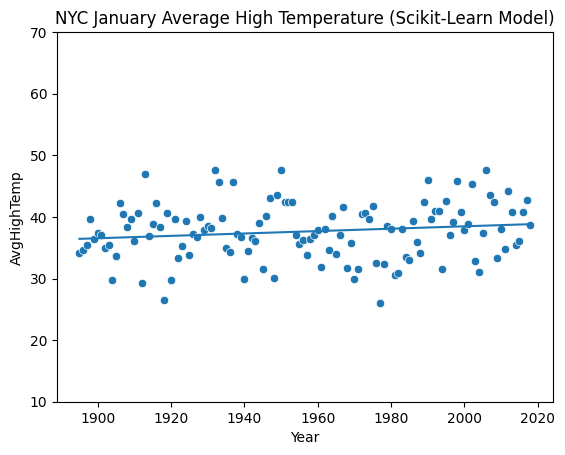

In [20]:
# Scatter plot of actual data
axes = sns.scatterplot(x="Year", y="AvgHighTemp", data=nyc_df)

# Create predictions for all years using the trained model
y_pred_all = linear_regression.predict(X)

# Plot regression line
plt.plot(nyc_df["Year"], y_pred_all)

axes.set_ylim(10, 70)
plt.title("NYC January Average High Temperature (Scikit-Learn Model)")
plt.show()

## Part 4 - Insights and Comparison

In this project, I used simple linear regression in two different ways: first with SciPy’s `linregress()` function and then with Scikit-Learn’s `LinearRegression` estimator.

When I used SciPy, the model was built using the entire dataset. The slope was approximately 0.0148, which shows a small upward trend in average January high temperatures in New York City over time. This suggests that temperatures have gradually increased, but the change per year is fairly small.

With Scikit-Learn, the dataset was split into training and testing sets before fitting the model. The slope from this model was approximately 0.0194, which is slightly different from the SciPy result. This difference makes sense because the Scikit-Learn model was trained on only part of the data rather than the full dataset.

Both models predicted the average January high temperature for 2024 to be around 39°F. The predictions were very close to each other, which shows that both approaches produced similar results overall. However, when comparing predicted values to actual test data, some predictions were several degrees off. This shows that while there is a general upward trend, the year alone does not strongly explain temperature variation.

The low correlation value also supports this conclusion. There is a slight linear relationship between year and temperature, but it is not strong. Many other factors likely influence temperature changes from year to year.

Overall, this project shows that linear regression is useful for identifying long-term trends, but it has limitations when trying to predict specific yearly outcomes. Comparing both methods helped me better understand how training data selection and model evaluation affect predictions.